# Этап 1. Отбор механики поиска

Этот ноутбук **не запускает LLM** и не считает метрики заново. Он только
**загружает** уже готовый артефакт прогона и **показывает** результаты в
удобном виде: таблицы, ранжирование стратегий, графики, итоговое решение
(memo).

## Что мы исследуем на этом этапе

На корпусе одной стоматологической клиники сравниваются разные способы
извлечения контекста для ответа: от простых правил до векторного и
гибридного поиска. Цель — **выбрать наиболее оправданную по соотношению
качество/сложность стратегию** и зафиксировать, какие усложнения
**не дают** прироста и потому не нужны в production.

Полный список сравниваемых стратегий (`B0/S1/S2/S3/S4` и опциональные
`S4r/S5`), их параметры, версии моделей и пороги — единый источник правды
лежит в [`d4/configs/experiment.yaml`](../configs/experiment.yaml). Здесь
эта информация сознательно не дублируется, чтобы не разъезжаться с
конфигом.

## Главная проверяемая гипотеза этапа 1

> Усложнение механики поиска (гибридный поиск, переранжирование,
> каскадная маршрутизация) даёт измеримый и устойчивый прирост
> качества ответа относительно простого векторного поиска.

В ходе ноутбука мы оценим эту гипотезу на выводе уже готового прогона
полного dev-набора (`run_id = 20260419_235319`, `n = 137`).

## Зафиксированные условия этапа 1

- Режим представления чанков — единственный: **обычное представление
  (`plain`, оно же `C0`)**. Влияние различных представлений изучается
  отдельно в Stage 2A; в этом ноутбуке оно намеренно не варьируется,
  чтобы изолировать эффект **самой механики поиска**.
- Параметры извлечения, эмбеддер, LLM, судья и пороги — фиксируются
  снимком конфигурации [`config_snapshot.yaml`](../outputs/runs/20260419_235319/config_snapshot.yaml)
  внутри прогона; этот снимок не модифицируется.

## Логика последовательности секций

Ноутбук устроен по принципу «от настройки прогона к интерпретации»:
сначала задаём, какой именно прогон анализируем (секции 1–2), затем при
необходимости запускаем новый прогон (секция 3), затем загружаем
артефакты (секция 4), сравниваем стратегии и формируем выводы (секции
5–7) и в финале фиксируем все полученные файлы (секция 8).


## 1. Конфигурация прогона

В этой секции задаётся, **какой прогон мы анализируем** и **в каком
режиме** работает ноутбук. Это единственное место, где меняются
параметры; все последующие ячейки берут значения отсюда.

Что задаётся:

- `RUN_MODE` — режим работы ноутбука:
  - `analyze_existing` (по умолчанию) — анализируем уже готовый прогон
    из `outputs/runs/{RUN_ID}/`, **новых LLM-вызовов не делается**;
  - `run_new` — запускаем новый прогон (через CLI runner), создаётся
    свежий каталог с текущим timestamp.
- `MODES = ["plain"]` — на этапе 1 фиксируем единственный режим
  представления чанков. Не меняйте этот список — варьирование
  представлений относится к Stage 2A.
- `EVAL_SET` — какой оценочный набор использовать (`pilot`, `full_dev`,
  `smoke`, `hard`, `blind`). По умолчанию — `full_dev` (137 сэмплов из
  `eval_set_dev_v2.yaml`).
- `RUN_ID_EXPLICIT` — конкретный идентификатор прогона для анализа.
  По умолчанию указан канонический полный dev-прогон `20260419_235319`.

После выполнения ячейки в выводе должны появиться выбранный `RUN_MODE`,
`RUN_ID`, `MODES`, оценочный набор и путь к каталогу прогона.


In [1]:
import sys
import logging
from pathlib import Path
from datetime import datetime

# Включаем logging, чтобы warnings из d4.analysis.loaders и других модулей
# были видны прямо в stdout ячейки (иначе "пустой DataFrame" выглядит как
# "ничего не произошло").
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s %(name)s: %(message)s",
    force=True,
)

# ──────────────────────────────────────────────
# Resolver STUDY_ROOT — не зависит от cwd ядра.
# Проверяем по маркерам: d4/configs/experiment.yaml и .venv/bin/python.
# ──────────────────────────────────────────────
_CANDIDATES = [
    Path("/Users/kazdoraw/developer/med-agent/study"),
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd().parent.parent.parent,
]

STUDY_ROOT = None
for _p in _CANDIDATES:
    if (_p / "d4" / "configs" / "experiment.yaml").exists() and (_p / ".venv" / "bin" / "python").exists():
        STUDY_ROOT = _p.resolve()
        break

assert STUDY_ROOT is not None, (
    "Не удалось определить STUDY_ROOT: ни один кандидат не содержит "
    "d4/configs/experiment.yaml и .venv/bin/python"
)

if str(STUDY_ROOT) not in sys.path:
    sys.path.insert(0, str(STUDY_ROOT))

# Если kernel стартовал из другой копии проекта (например, ai-core/apps/agent-llm),
# `d4` мог попасть в sys.modules ДО нашего insert(0, STUDY_ROOT). Тогда from d4...
# возьмёт закэшированную ai-core-копию без наших правок. Чистим кэш, чтобы
# следующий импорт подхватил d4 из STUDY_ROOT.
for _mod in [m for m in sys.modules if m == "d4" or m.startswith("d4.")]:
    del sys.modules[_mod]

from d4.analysis.artifacts import make_run_paths, list_run_artifacts, latest_run_id
from d4.analysis.preflight import run_preflight
from d4.analysis.loaders import load_reports, load_rank_analysis
from d4.analysis.representation_compare import (
    build_retrieval_table, build_deterministic_table, evaluate_gate, rank_modes,
)
from d4.analysis.plots import (
    plot_retrieval_comparison, plot_quality_comparison, plot_mode_deltas, plot_rank_shift,
)
from d4.analysis.reporting import generate_stage2_memo
from d4.config import load_config

# Sanity-check: d4 действительно импортировался из STUDY_ROOT.
import d4 as _d4
_d4_path = Path(_d4.__file__).resolve().parent
assert _d4_path == (STUDY_ROOT / "d4"), (
    f"d4 импортирован из {_d4_path}, ожидалось {STUDY_ROOT / 'd4'}. "
    "Вероятно, в sys.path есть другая копия проекта. Сделайте Kernel → Restart."
)

# ──────────────────────────────────────────────
# Параметры прогона (единственное место настройки)
# ──────────────────────────────────────────────
# RUN_MODE:
#   "run_new"          — запустить LLM-прогон заново, RUN_ID = текущий timestamp.
#   "analyze_existing" — только анализ существующего прогона, subprocess-ячейка
#                         пропускается. RUN_ID должен быть явно указан
#                         (или None → возьмём latest_run_id()).
RUN_MODE = "analyze_existing"   # "run_new" | "analyze_existing"

# Stage 1 фокусируется ТОЛЬКО на стратегиях поиска,
# поэтому представление зафиксировано как plain (C0).
MODES = ["plain"]
EVAL_SET = "full_dev"          # "pilot" | "full_dev" | "smoke" | "hard" | "blind"
USE_EXPERIMENTAL = False

# RUN_ID — явный id прогона. Для analyze_existing обязателен (или None → latest).
# Для run_new игнорируется и перезаписывается текущим timestamp'ом.
# По умолчанию используем общий run, в котором уже есть full_dev_plain.
RUN_ID_EXPLICIT = "20260419_235319"

assert RUN_MODE in ("run_new", "analyze_existing"), (
    f"Невалидный RUN_MODE={RUN_MODE!r}. Допустимые: 'run_new' | 'analyze_existing'"
)

if RUN_MODE == "run_new":
    RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
else:
    RUN_ID = RUN_ID_EXPLICIT or latest_run_id()
    assert RUN_ID is not None, (
        "RUN_MODE='analyze_existing', но RUN_ID_EXPLICIT=None и нет ни одного "
        "существующего run в outputs/runs/. Укажите RUN_ID_EXPLICIT явно."
    )

# Маппинг EVAL_SET → CLI-флаг и run_name для loaders
_EVAL_SET_CONFIG = {
    "pilot":    {"flags": ["--pilot"],    "run_name": "pilot_dev_30",
                 "eval_path": "d4/outputs/pilot_dev_30.yaml"},
    "full_dev": {"flags": ["--full-dev"], "run_name": "full_dev",
                 "eval_path": "d4/data/eval_set_dev_v2.yaml"},
    "smoke":    {"flags": [],             "run_name": "smoke",
                 "eval_path": "d4/tests/mini_eval_set.yaml"},
    "hard":     {"flags": ["--hard"],     "run_name": "hard",
                 "eval_path": "d4/tests/mini_eval_set_hard.yaml"},
    "blind":    {"flags": ["--blind"],    "run_name": "blind",
                 "eval_path": "d4/tests/blind_hard_holdout.yaml"},
}
assert EVAL_SET in _EVAL_SET_CONFIG, (
    f"Невалидный EVAL_SET='{EVAL_SET}'. "
    f"Допустимые: {list(_EVAL_SET_CONFIG.keys())}"
)
RUN_NAME = _EVAL_SET_CONFIG[EVAL_SET]["run_name"]

run_paths = make_run_paths(RUN_ID)
config = load_config(STUDY_ROOT / "d4" / "configs" / "experiment.yaml")

print(f"Run mode: {RUN_MODE}")
print(f"Run ID:   {RUN_ID}")
print(f"Modes:    {MODES}  (Stage 1: единственный режим — plain)")
print(f"Eval set: {EVAL_SET} (run_name={RUN_NAME})")
print(f"Run dir:  {run_paths.run_dir}")


Run mode: analyze_existing
Run ID:   20260419_235319
Modes:    ['plain']  (Stage 1: единственный режим — plain)
Eval set: full_dev (run_name=full_dev)
Run dir:  /Users/kazdoraw/developer/med-agent/study/d4/outputs/runs/20260419_235319


## 2. Предполётная проверка

Прежде чем что-то загружать или запускать, ноутбук убеждается, что
**всё нужное на месте и согласовано между собой**. Цель — рано отловить
ошибки конфигурации, отсутствующие файлы или несоответствие хешей кеша.

Что проверяется (источник правды — `d4/analysis/preflight.py`):

- наличие `chunks_frozen.json` и выбранного `eval_set_*.yaml`;
- что Python-окружение запущено из `d4/.venv`;
- что для выбранного режима `plain` существуют артефакты прогона
  (`{run_name}_plain.jsonl` + `{run_name}_plain.report.json`);
- что снимок конфигурации (`config_snapshot.yaml`) внутри прогона есть
  и соответствует выбранному режиму;
- хеши кеша обогащений (важно для воспроизводимости C2 в Stage 2A,
  здесь — для уверенности, что прогон собран целостно).

В выводе ожидаются строки `✓ <название проверки>`. Любая запись `✗`
вызовет `assert pf.ok` и остановит ноутбук — это нужно: дальше
запускать смысла нет, пока проблема не устранена.


In [2]:
pf = run_preflight(
    config,
    MODES,
    run_paths,
    run_name=RUN_NAME,
    expect_existing=(RUN_MODE == "analyze_existing"),
)
print(pf.summary())
assert pf.ok, "Preflight FAILED — исправьте проблемы перед запуском"


Preflight: PASS
  ✓ chunks_frozen  (/Users/kazdoraw/developer/med-agent/study/d4/data/chunks_frozen.json)
  ✓ eval_set  (/Users/kazdoraw/developer/med-agent/study/d4/data/eval_set_dev_v2.yaml)
  ✓ python_venv  (prefix=/Users/kazdoraw/developer/med-agent/study/.venv)
  ✓ artifacts_plain  (full_dev_plain.jsonl + full_dev_plain.report.json)
  ✓ config_mode_plain  (config.mode=plain)
  ✓ cache_prompt_version  (prompt_version=v2-classaware-strict64)
  ✓ cache_prompts_hash  (prompts_hash=086d0a59)
  ✓ cache_content_hash  (content_hash=dd15dd888a00, n_chunks=63)
  ✓ cache_params  (mode=plain, c2_max_tokens=64, c2_temp=0.0)
  ✓ config_snapshot  (/Users/kazdoraw/developer/med-agent/study/d4/outputs/runs/20260419_235319/config_snapshot.yaml)
  ✓ dry_summary  (modes=['plain'], strategies=['Full Context', 'Lexical Retrieval', 'Vector Retrieval', 'Hybrid Retrieval'], eval_set=eval_set_dev_v2.yaml)


## 3. Запуск нового LLM-прогона (только при `RUN_MODE = "run_new"`)

Эта секция — **единственное место в ноутбуке, где могут идти платные
LLM-вызовы**. По умолчанию она ничего не делает: при
`RUN_MODE = "analyze_existing"` ноутбук работает с уже сохранённым
прогоном из секции 1 и просто печатает «пропускаю».

Когда секция действительно запускается:

- ноутбук вызывает CLI runner `d4/tests/mini_llm_run.py` через
  `subprocess` для каждого режима из `MODES` (на этапе 1 это только
  `plain`);
- runner проходит по оценочному набору, для каждого вопроса вызывает
  каждую сравниваемую стратегию извлечения, формирует контекст и
  посылает запрос в LLM-судью;
- результаты сохраняются в новый каталог
  `outputs/runs/{новый_timestamp}/` вместе со снимком конфигурации и
  логом запусков.

Все последующие секции читают эти артефакты — **сами они LLM не
дёргают**, поэтому повторный анализ полностью бесплатный и
воспроизводимый.


In [3]:
import subprocess

# Guard: в analyze-режиме LLM не запускается — используем уже готовые отчёты.
# Безопасно для Run All: просто выводим сообщение и не входим в цикл.
if RUN_MODE == "analyze_existing":
    print(f"⏭  Skip: RUN_MODE={RUN_MODE!r} — LLM-прогон не запускается, "
          f"используем существующие отчёты из {run_paths.run_dir}")
else:
    PYTHON = str(STUDY_ROOT / ".venv" / "bin" / "python")
    RUNNER = str(STUDY_ROOT / "d4" / "tests" / "mini_llm_run.py")
    eval_flags = _EVAL_SET_CONFIG[EVAL_SET]["flags"]

    for mode in MODES:
        print(f"\n{'='*60}")
        print(f"Запуск mode={mode}, eval_set={EVAL_SET}...")
        print(f"{'='*60}\n")

        cmd = [PYTHON, RUNNER, "--run-id", RUN_ID, "--representation", mode]
        cmd.extend(eval_flags)
        if USE_EXPERIMENTAL:
            cmd.append("--experimental")

        result = subprocess.run(cmd, cwd=str(STUDY_ROOT), capture_output=False)

        if result.returncode != 0:
            print(f"⚠ mode={mode} завершился с кодом {result.returncode}")
        else:
            print(f"✓ mode={mode} завершён успешно")


⏭  Skip: RUN_MODE='analyze_existing' — LLM-прогон не запускается, используем существующие отчёты из /Users/kazdoraw/developer/med-agent/study/d4/outputs/runs/20260419_235319


## 4. Загрузка отчётов прогона

Здесь поднимаются результаты выбранного в секции 1 прогона: для каждого
режима представления (на этапе 1 это только `plain`) грузятся файлы
`{run_name}_{mode}.report.json` и `{run_name}_{mode}.jsonl`.

Что получается на выходе:

- `reports_df` — длинный DataFrame с метриками по каждой стратегии в
  каждом режиме (одна строка = одно значение метрики);
- `rank_df` — табличка для расчёта ранговых метрик retrieval по
  per-sample данным (используется в секциях 5 и 6);
- `meta_dict` — мета-информация о прогоне (`run_id`, `run_name`, размер
  оценочного набора, версия промпта, хеши кеша).

В выводе печатаются: количество строк в `reports_df`, перечень режимов
и стратегий, найденных в прогоне, и первые строки таблицы — это нужно,
чтобы убедиться, что данные действительно загружены и в нужной
структуре.


In [4]:
import importlib
import d4.analysis.loaders, d4.analysis.representation_compare, d4.analysis.plots, d4.analysis.reporting
importlib.reload(d4.analysis.loaders)
importlib.reload(d4.analysis.representation_compare)
importlib.reload(d4.analysis.plots)
importlib.reload(d4.analysis.reporting)
from d4.analysis.loaders import load_report, load_reports, load_rank_analysis
from d4.analysis.representation_compare import build_retrieval_table, build_deterministic_table, evaluate_gate, rank_modes
from d4.analysis.plots import plot_retrieval_comparison, plot_quality_comparison, plot_mode_deltas, plot_rank_shift
from d4.analysis.reporting import generate_stage2_memo

reports_df = load_reports(RUN_ID, MODES, run_name=RUN_NAME)
rank_df = load_rank_analysis(RUN_ID, MODES, run_name=RUN_NAME)

# ── fail-fast: защита от "молча пустого" DataFrame ────────────────────────────
assert not reports_df.empty, (
    f"Не найдено ни одного report.json для run_id={RUN_ID}, "
    f"run_name={RUN_NAME}, modes={MODES}"
)
loaded_modes = set(reports_df["mode"].unique())
assert loaded_modes == set(MODES), (
    f"Загружены не все режимы: got={sorted(loaded_modes)}, expected={sorted(MODES)}"
)

# ── meta-sanity: защита от "full_dev в тексте vs pilot в данных" ──────────────
run_meta = {m: load_report(RUN_ID, m, run_name=RUN_NAME).get("meta", {}) for m in MODES}
for m, meta in run_meta.items():
    assert meta.get("run_id") == RUN_ID, (
        f"meta.run_id mismatch для mode={m}: meta={meta.get('run_id')!r}, expected={RUN_ID!r}"
    )
    assert meta.get("run_name") == RUN_NAME, (
        f"meta.run_name mismatch для mode={m}: meta={meta.get('run_name')!r}, expected={RUN_NAME!r}"
    )
    assert meta.get("representation_mode") == m, (
        f"meta.representation_mode mismatch: meta={meta.get('representation_mode')!r}, expected={m!r}"
    )

n_samples_set = {meta.get("n_samples") for meta in run_meta.values()}
assert len(n_samples_set) == 1, f"n_samples рассинхронизировано между modes: {n_samples_set}"

if RUN_NAME == "full_dev":
    n_samples = next(iter(n_samples_set))
    assert n_samples == 137, f"full_dev ожидает n_samples=137, получено {n_samples}"

print(f"Reports: {len(reports_df)} rows, modes: {sorted(loaded_modes)}")
print(f"Rank analysis: {rank_df.shape}")
print(f"Meta OK: run_id={RUN_ID}, run_name={RUN_NAME}, n_samples={next(iter(n_samples_set))}")
print(f"Strategies in run: {sorted(reports_df['strategy'].unique())}")
reports_df.head(10)


Reports: 75 rows, modes: ['plain']
Rank analysis: (121, 3)
Meta OK: run_id=20260419_235319, run_name=full_dev, n_samples=137
Strategies in run: ['B0', 'S1', 'S2', 'S3', 'S4']


,mode,strategy,section,metric,value
0,plain,B0,quality,n,137.000
1,plain,B0,quality,answerable_true,125.000
2,plain,B0,quality,avg_confidence,0.530
3,plain,B0,quality,avg_latency_ms,4.000
4,plain,S1,quality,n,137.000
5,plain,S1,quality,answerable_true,122.000
6,plain,S1,quality,avg_confidence,0.898
7,plain,S1,quality,avg_latency_ms,2784.000
8,plain,S2,quality,n,137.000
9,plain,S2,quality,answerable_true,93.000


## 5. Сравнение стратегий поиска

Это **ключевая аналитическая секция этапа 1**. Здесь мы смотрим, как
разные механики извлечения контекста ведут себя на одном и том же
наборе вопросов при одинаковом представлении чанков.

Что получается в выводе:

1. **Таблица retrieval-метрик** — насколько хорошо каждая стратегия
   *находит* нужную информацию: попадание эталонного чанка в топ
   (`hit@5`), позиция первого попадания (`MRR`), полнота
   (`mean_recall`), доля случаев с эталоном в контексте
   (`gold_in_context_rate`). Стратегия `S1` (полный контекст) в этой
   таблице не участвует, потому что у неё ретрив тривиален.
2. **Таблица качества ответа** — что произошло уже после извлечения:
   доля корректных решений отвечать/отказать (`answerability_rate`),
   доля ответов с правильно подобранным врачом (`doctor_match_rate`),
   доля покрытых обязательных фактов (`avg_fmr`), число неподтверждённых
   утверждений (`unsupported_claims`).
3. **Длинный ранг стратегий** — для каждой важной метрики стратегии
   ранжируются от лучшей к худшей (используется как сырой материал
   для memo и графиков).
4. **Сводный pivot** — компактная таблица «метрика × стратегия» с
   рангом в скобках, для быстрого взгляда на лидера и аутсайдера.
5. **Текстовый вердикт этапа 1** — короткое резюме: кто лидирует по
   ретриву, у кого выше FMR, кто слабее всех и есть ли смысл
   усложнять до `S4/S4r`.

Замечание: **Decision Gate в этой секции неинформативен** — он
рассчитан на сравнение режимов представления и в single-mode прогоне
этапа 1 даёт нулевые delta. Опираемся именно на ранг стратегий и
вердикт, а не на gate-флаги.


In [5]:
import pandas as pd
from d4.analysis.reporting import rank_strategies, _stage1_verdict

mode = MODES[0]

# 1) Базовые таблицы по run-у (одна строка = одна стратегия).
ret_table = build_retrieval_table(reports_df)
det_table = build_deterministic_table(reports_df)


def _drop_delta_cols(df: pd.DataFrame) -> pd.DataFrame:
    """В single-mode прогоне delta-колонки (vs plain) тривиально нулевые —
    отбрасываем, чтобы таблица читалась.
    """
    return df[[c for c in df.columns if not c.endswith("::delta")]]


# 2) Retrieval-таблица: только содержательные ретрив-метрики.
_RET_COLS = [
    f"{mode}::hit_rate",
    f"{mode}::mrr",
    f"{mode}::mean_recall",
    f"{mode}::gold_in_context_rate",
]
ret_view = _drop_delta_cols(ret_table)[
    [c for c in _RET_COLS if c in ret_table.columns]
].rename(columns=lambda c: c.split("::", 1)[1])

print(f"=== Метрики ретрива (режим представления = {mode}) ===")
print("Чем выше — тем лучше. Стратегии без ретрива (B0, S1) здесь не показаны.")
display(ret_view.round(4))

# 3) Quality-таблица: только метрики итогового ответа.
_QUAL_COLS = [
    f"{mode}::avg_fmr",
    f"{mode}::doctor_match_rate",
    f"{mode}::answerability_rate",
    f"{mode}::unsupported_claims",
]
qual_view = _drop_delta_cols(det_table)[
    [c for c in _QUAL_COLS if c in det_table.columns]
].rename(columns=lambda c: c.split("::", 1)[1])

print(f"\n=== Метрики качества ответа (режим представления = {mode}) ===")
print(
    "FMR / doctor_match_rate / answerability_rate — больше = лучше; "
    "unsupported_claims — меньше = лучше."
)
display(qual_view.round(4))

# 4) Ранжирование стратегий по каждой метрике + сводный pivot.
ranking_df = rank_strategies(ret_table, det_table, mode=mode)


def _ranking_pivot(rdf: pd.DataFrame) -> pd.DataFrame:
    """Pivot ranking_df → метрика × стратегия со значением и рангом
    в скобках, например ``"0.6190 (1)"``.
    """
    if rdf.empty:
        return pd.DataFrame()
    rdf = rdf.copy()
    rdf["cell"] = rdf.apply(
        lambda r: f"{r['value']:.4f} ({int(r['rank'])})", axis=1
    )
    return rdf.pivot(index="metric", columns="strategy", values="cell").fillna("—")


print("\n=== Сводный ранг стратегий: значение метрики и место (1 — лучшее) ===")
print(
    "Колонки — стратегии, строки — метрики. "
    "В каждой ячейке: значение и место в ранжировании по этой метрике."
)
display(_ranking_pivot(ranking_df))

# 5) Числовая интерпретация: разрыв между лучшей и худшей retrieval-стратегией
#    по FMR и расстояние до upper-bound (S1 = полный контекст).
verdict = _stage1_verdict(ranking_df)


def _safe(pair, default="—"):
    return pair if pair is not None else (default, None)


retr_leader = verdict.get("retrieval_leader") or "—"
fmr_leader_name, fmr_leader_val = _safe(verdict.get("fmr_leader_retrieval"))
fmr_ub_name, fmr_ub_val = _safe(verdict.get("fmr_upper_bound"))
weakest_name, weakest_val = _safe(verdict.get("weakest_retrieval"))

print("\n=== Вердикт этапа 1 ===")
print(f"  • Лидер ретрива:                        {retr_leader}")
print(f"  • Лидер по FMR среди retrieval:         {fmr_leader_name}"
      + (f" = {fmr_leader_val:.4f}" if fmr_leader_val is not None else ""))
print(f"  • Upper-bound по FMR (полный контекст): {fmr_ub_name}"
      + (f" = {fmr_ub_val:.4f}" if fmr_ub_val is not None else ""))
print(f"  • Слабейшая retrieval-стратегия:        {weakest_name}"
      + (f" = {weakest_val:.4f}" if weakest_val is not None else ""))

if fmr_leader_val is not None and weakest_val is not None:
    print(
        f"\n  Δ FMR (лидер retrieval − слабейший retrieval): "
        f"{fmr_leader_val - weakest_val:+.4f}"
    )
if fmr_leader_val is not None and fmr_ub_val is not None:
    gap = fmr_ub_val - fmr_leader_val
    print(
        f"  Δ FMR (upper-bound {fmr_ub_name} − лидер retrieval {fmr_leader_name}): "
        f"{gap:+.4f}"
        + (
            "  → ретрив отстаёт от полного контекста"
            if gap > 0
            else "  → ретрив достиг (или превзошёл) полный контекст"
        )
    )


=== Метрики ретрива (режим представления = plain) ===
Чем выше — тем лучше. Стратегии без ретрива (B0, S1) здесь не показаны.


,hit_rate,mrr,mean_recall,gold_in_context_rate
strategy,,,,
S2,0.6446,0.5855,0.5944,0.5455
S3,0.9504,0.8380,0.8967,0.8264
S4,0.9008,0.7712,0.8671,0.8182



=== Метрики качества ответа (режим представления = plain) ===
FMR / doctor_match_rate / answerability_rate — больше = лучше; unsupported_claims — меньше = лучше.


,avg_fmr,doctor_match_rate,answerability_rate,unsupported_claims
strategy,,,,
B0,0.3280,0.6087,0.8540,0.0
S1,0.6562,1.0000,0.9781,0.0
S2,0.4525,0.7826,0.7956,0.0
S3,0.6190,0.9565,0.9781,0.0
S4,0.6076,0.9130,0.9489,0.0



=== Сводный ранг стратегий: значение метрики и место (1 — лучшее) ===
Колонки — стратегии, строки — метрики. В каждой ячейке: значение и место в ранжировании по этой метрике.


strategy,B0,S1,S2,S3,S4
metric,,,,,
Answerability Rate,0.8540 (4),0.9781 (1),0.7956 (5),0.9781 (1),0.9489 (3)
Doctor Match Rate,0.6087 (5),1.0000 (1),0.7826 (4),0.9565 (2),0.9130 (3)
Fact Match Rate,0.3280 (5),0.6562 (1),0.4525 (4),0.6190 (2),0.6076 (3)
MRR,—,—,0.5855 (3),0.8380 (1),0.7712 (2)
Mean Recall@5,—,—,0.5944 (3),0.8967 (1),0.8671 (2)
hit@5,—,—,0.6446 (3),0.9504 (1),0.9008 (2)



=== Вердикт этапа 1 ===
  • Лидер ретрива:                        S3
  • Лидер по FMR среди retrieval:         S3 = 0.6190
  • Upper-bound по FMR (полный контекст): S1 = 0.6562
  • Слабейшая retrieval-стратегия:        S2 = 0.4525

  Δ FMR (лидер retrieval − слабейший retrieval): +0.1665
  Δ FMR (upper-bound S1 − лидер retrieval S3): +0.0372  → ретрив отстаёт от полного контекста


## 5.5 Парная статистическая значимость — на этапе 1 не применяется

Реализованные в `d4.analysis.significance` бутстрэп-доверительные
интервалы и парные тесты сконструированы для проверки **разницы между
режимами представления чанков** (`plain` vs `contextual` vs
`llm_enriched`). На этапе 1 у нас единственный режим `plain`, поэтому
парный тест попросту не имеет смысла — сравнивать не с чем.

Сравнение значимости **между разными стратегиями** внутри одного режима
(например, `S3` vs `S4` на `plain`) — это другой класс тестов и в
данной кодовой базе пока не реализовано. Эта секция оставлена в
структуре, чтобы не нарушать сквозной порядок ноутбуков (для Stage 2A
она содержательная). Здесь же она просто печатает заметку и
устанавливает `sig_df = None`.


In [6]:
print("⏭  Stage 1 single-mode: significance секция не применима (см. markdown выше).")
sig_df = None


⏭  Stage 1 single-mode: significance секция не применима (см. markdown выше).


## 6. Графики

Из таблиц секции 5 строятся **две сводные диаграммы по стратегиям**.
Цель — визуально подкрепить вердикт и дать читателю одну картинку, на
которую можно сослаться в отчёте/докладе.

1. **Графики ретрива** — для каждой retrieval-метрики
   (`hit@5`, `MRR`, `mean_recall@5`, `gold_in_context`) показывают
   столбец на каждую стратегию. Высота столбца — значение метрики на
   полном dev-наборе. Сразу видно, какая механика лучше «доносит»
   нужный чанк до LLM.
2. **Графики качества ответа** — для метрик `FMR`, `doctor_match_rate`,
   `answerability_rate` показывают столбец на каждую стратегию.
   Здесь видно, как улучшение ретрива (или его отсутствие) превращается
   в качество финального ответа.

Графики, рассчитанные на сравнение режимов представления
(`mode_deltas`, `rank_shift`), здесь сознательно не строятся: на этапе
1 режим один, поэтому они показывали бы пустые delta и только
запутывали бы. Их место — в ноутбуке Stage 2A.

Файлы PNG сохраняются в каталог прогона (`outputs/runs/{RUN_ID}/figures/`)
и затем индексируются в секции 8.


Figures will be written to: /Users/kazdoraw/developer/med-agent/study/d4/outputs/runs/20260419_235319/figures


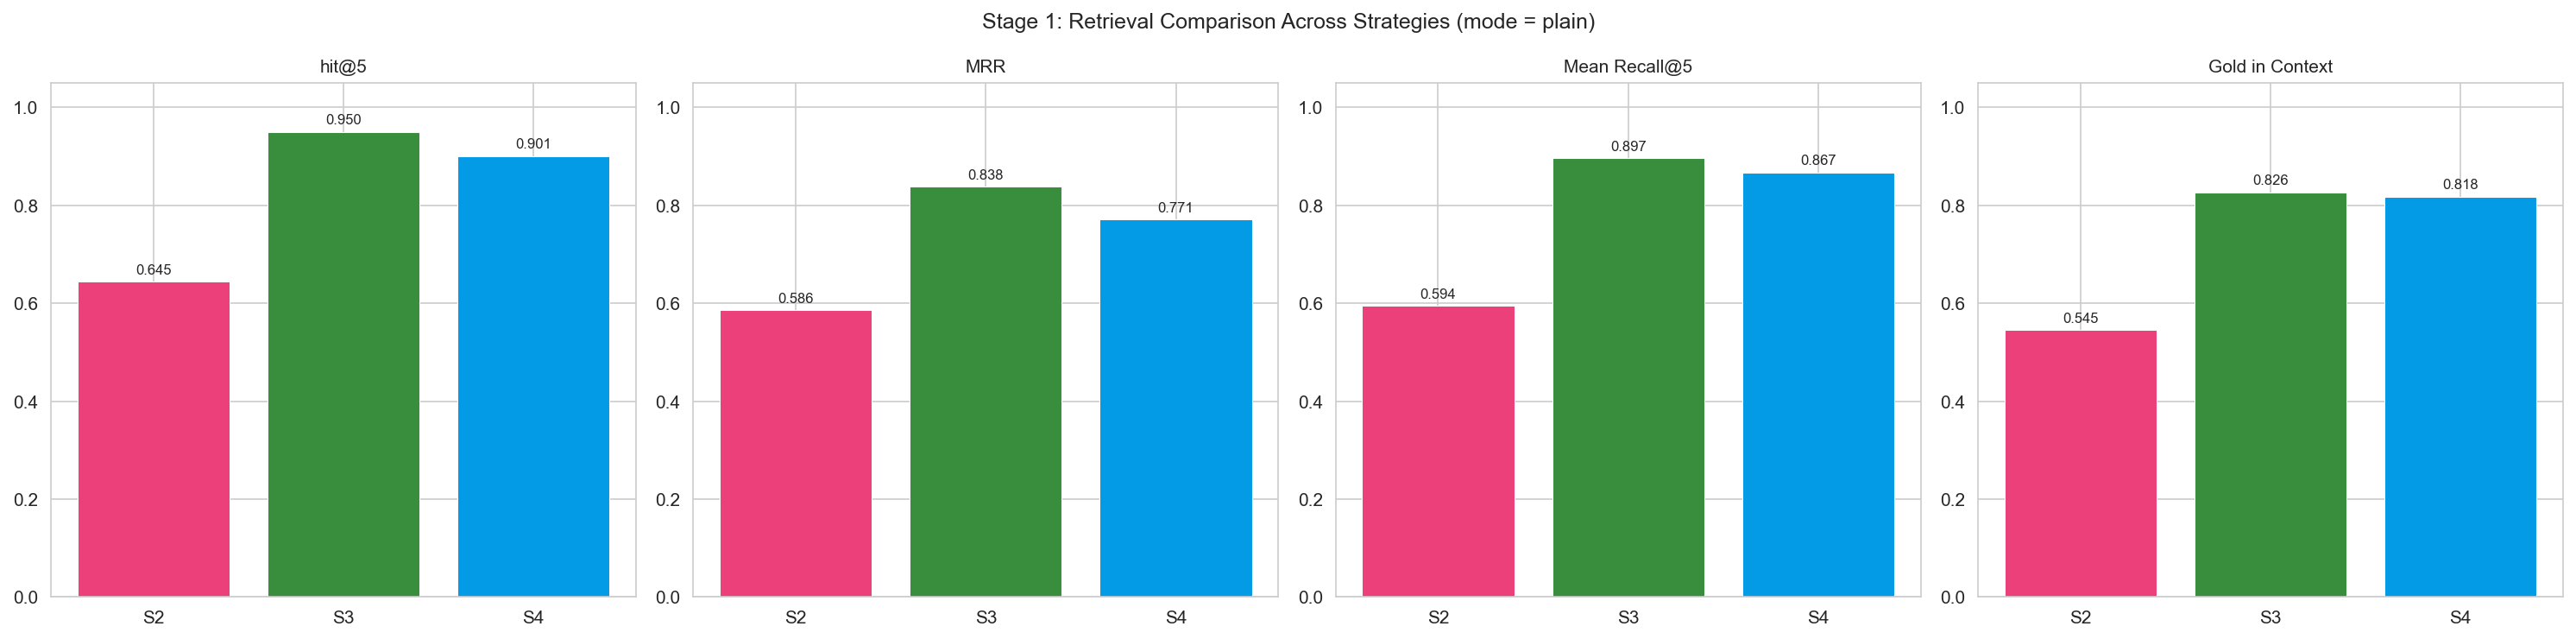

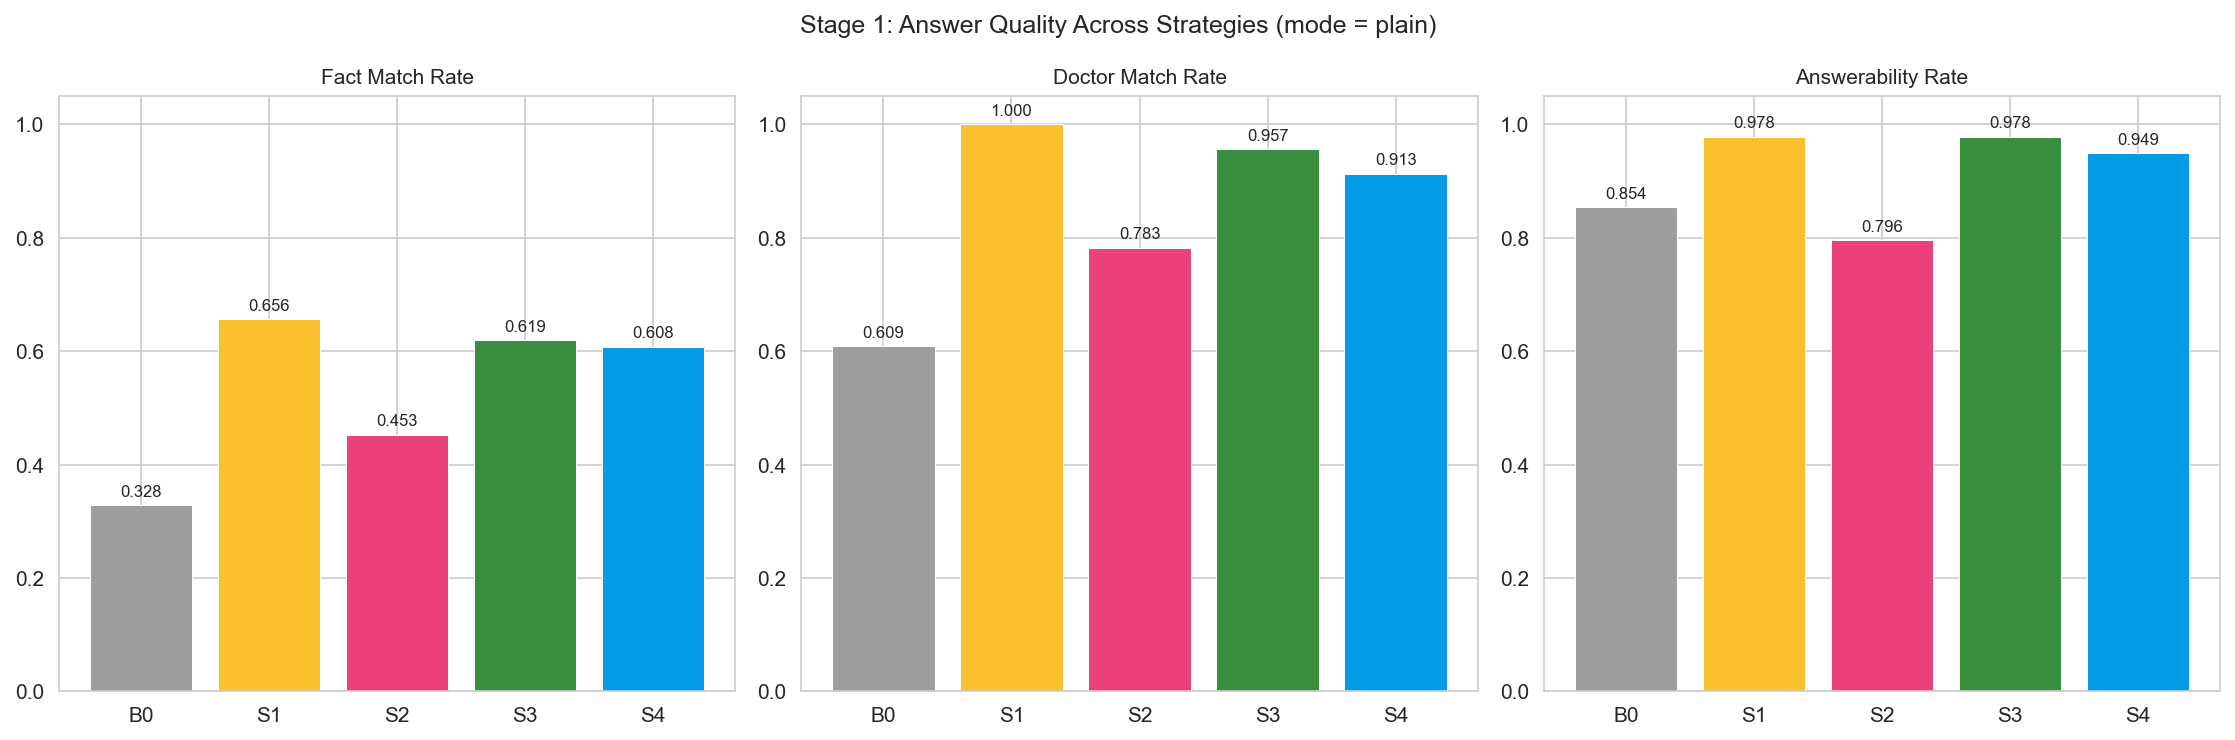


Сохранено 2 графиков в /Users/kazdoraw/developer/med-agent/study/d4/outputs/runs/20260419_235319/figures


In [7]:
from IPython.display import Image, display as ipy_display
from d4.analysis.plots import (
    plot_stage1_retrieval_strategies,
    plot_stage1_quality_strategies,
)

# Destination sanity: figures должны уехать в run_dir текущего RUN_ID,
# а не в старый kernel-state.
assert run_paths.run_id == RUN_ID, (
    f"run_paths.run_id={run_paths.run_id!r} != RUN_ID={RUN_ID!r} — "
    "ячейка 3 (Run Config) не была перезапущена после смены RUN_ID."
)
print(f"Figures will be written to: {run_paths.figures_dir}")

figures = []

fig_ret = plot_stage1_retrieval_strategies(ret_table, run_paths, mode=MODES[0])
figures.append(fig_ret)
ipy_display(Image(filename=str(fig_ret)))

fig_qual = plot_stage1_quality_strategies(det_table, run_paths, mode=MODES[0])
figures.append(fig_qual)
ipy_display(Image(filename=str(fig_qual)))

print(f"\nСохранено {len(figures)} графиков в {run_paths.figures_dir}")


## 7. Итоговое решение этапа (decision memo)

В этой секции таблицы и графики собираются в **одностраничный
markdown-документ — decision memo этапа 1**. Это текстовый артефакт,
который потом цитируется в основном отчёте ВКР и в командных
обсуждениях.

Структура memo (формируется автоматически в
`generate_stage1_memo`, см. `d4/analysis/reporting.py`):

- метаданные прогона (`run_id`, размер оценочного набора, версия
  промпта);
- таблица retrieval-метрик и таблица качества ответа в pivot-форме;
- ранжирование стратегий по каждой метрике;
- текстовый вердикт: какая стратегия лидер по ретриву, какая по FMR,
  кто слабейший, и какие выводы это даёт для последующих этапов;
- ссылки на сохранённые графики из секции 6.

Сам файл сохраняется в
`outputs/runs/{RUN_ID}/reports/stage1_decision_memo.md`. Под кодовой
ячейкой ниже его содержимое также сразу рендерится в ноутбуке —
чтобы прямо здесь было видно итог, не уходя в файловую систему.


In [8]:
from IPython.display import Markdown
from d4.analysis.reporting import generate_stage1_memo

assert run_paths.run_id == RUN_ID, (
    f"run_paths.run_id={run_paths.run_id!r} != RUN_ID={RUN_ID!r} — "
    "ячейка 3 (Run Config) не была перезапущена после смены RUN_ID."
)
print(f"Memo will be written to: {run_paths.reports_dir}")

# Stage 1-специфичный memo: ranking стратегий + текстовый verdict.
memo_path = generate_stage1_memo(
    ret_table,
    det_table,
    run_paths,
    figures=figures,
    run_meta=run_meta,
    mode=MODES[0],
    memo_filename="stage1_decision_memo.md",
)
print(f"Memo: {memo_path}")
display(Markdown(memo_path.read_text(encoding="utf-8")))


Memo will be written to: /Users/kazdoraw/developer/med-agent/study/d4/outputs/runs/20260419_235319/reports
Memo: /Users/kazdoraw/developer/med-agent/study/d4/outputs/runs/20260419_235319/reports/stage1_decision_memo.md


# Stage 1 Screening Decision Memo

> **Source of truth**: `outputs/runs/20260419_235319/`

**Run ID**: `20260419_235319`  
**Timestamp**: 2026-05-04 16:05 UTC  
**Mode (representation)**: `plain`

**Eval samples**: `137`  ·  **Elapsed**: `728.2s`

---

## 1. Retrieval Comparison (mode = `plain`)

| strategy   |   plain::gold_in_context_rate |   plain::hit_rate |   plain::mean_recall |   plain::mrr |   plain::n_samples |
|:-----------|------------------------------:|------------------:|---------------------:|-------------:|-------------------:|
| S2         |                        0.5455 |            0.6446 |               0.5944 |       0.5855 |           121.0000 |
| S3         |                        0.8264 |            0.9504 |               0.8967 |       0.8380 |           121.0000 |
| S4         |                        0.8182 |            0.9008 |               0.8671 |       0.7712 |           121.0000 |

## 2. Quality Comparison (mode = `plain`)

| strategy   |   plain::answerability_correct |   plain::avg_fmr |   plain::doctor_match |   plain::doctor_total |   plain::fmr_annotated |   plain::n |   plain::total_claims |   plain::unsupported_claims |   plain::answerability_rate |   plain::doctor_match_rate |
|:-----------|-------------------------------:|-----------------:|----------------------:|----------------------:|-----------------------:|-----------:|----------------------:|----------------------------:|----------------------------:|---------------------------:|
| B0         |                       117.0000 |           0.3280 |               14.0000 |               23.0000 |               121.0000 |   137.0000 |              282.0000 |                      0.0000 |                      0.8540 |                     0.6087 |
| S1         |                       134.0000 |           0.6562 |               23.0000 |               23.0000 |               121.0000 |   137.0000 |              319.0000 |                      0.0000 |                      0.9781 |                     1.0000 |
| S2         |                       109.0000 |           0.4525 |               18.0000 |               23.0000 |               121.0000 |   137.0000 |              306.0000 |                      0.0000 |                      0.7956 |                     0.7826 |
| S3         |                       134.0000 |           0.6190 |               22.0000 |               23.0000 |               121.0000 |   137.0000 |              327.0000 |                      0.0000 |                      0.9781 |                     0.9565 |
| S4         |                       130.0000 |           0.6076 |               21.0000 |               23.0000 |               121.0000 |   137.0000 |              307.0000 |                      0.0000 |                      0.9489 |                     0.9130 |

## 3. Strategy Ranking

| strategy   | Answerability Rate   | Doctor Match Rate   | Fact Match Rate   | MRR         | Mean Recall@5   | hit@5       |
|:-----------|:---------------------|:--------------------|:------------------|:------------|:----------------|:------------|
| S2         | 0.7956 (#5)          | 0.7826 (#4)         | 0.4525 (#4)       | 0.5855 (#3) | 0.5944 (#3)     | 0.6446 (#3) |
| S3         | 0.9781 (#1)          | 0.9565 (#2)         | 0.6190 (#2)       | 0.8380 (#1) | 0.8967 (#1)     | 0.9504 (#1) |
| S4         | 0.9489 (#3)          | 0.9130 (#3)         | 0.6076 (#3)       | 0.7712 (#2) | 0.8671 (#2)     | 0.9008 (#2) |
| S1         | 0.9781 (#1)          | 1.0000 (#1)         | 0.6562 (#1)       | —           | —               | —           |
| B0         | 0.8540 (#4)          | 0.6087 (#5)         | 0.3280 (#5)       | —           | —               | —           |

_Каждая ячейка: значение метрики и её ранг (`#1` — лучшая стратегия по этой метрике; для всех текущих Stage 1-метрик «больше — лучше»)._

## 4. Stage 1 Verdict

Лидер retrieval: **S3** (3 первое место(а) среди 3 retrieval-метрик). Лидер по FMR среди retrieval: **S3 = 0.6190**. Upper-bound по FMR: **S1 = 0.6562** (не retrieval-стратегия — даёт LLM весь контекст). Слабейшая retrieval-стратегия по FMR: **S2 = 0.4525**.

- **Лидер retrieval (по числу первых мест)**: `S3`.
- **Лидер по FMR среди retrieval-стратегий**: `S3` = `0.6190`.
- **Upper-bound по FMR (overall)**: `S1` = `0.6562`. Если это `S1` — это не retrieval-стратегия, а полный контекст.
- **Слабейшая retrieval-стратегия по FMR**: `S2` = `0.4525`.

## 5. Limitations

- Метрики получены на режиме `plain` (Stage 1 фиксирует представление чанков).
  Эффект различных представлений измеряется в Stage 2A.
- Decision Gate (`evaluate_gate`) не применяется в Stage 1: он рассчитан на сравнение режимов представления (delta-колонок), а в single-mode прогоне их нет.
- Per-sample `FMR` не сохраняется (`save_judge_scores` не вызывается в pipeline) — paired significance по FMR недоступен.
- На текущей итерации не прогонялись `hard` / `blind` eval-сеты, поэтому stress-валидация ранжирования стратегий вне `dev_v2` остаётся открытым шагом.

## 6. Figures

![stage1_retrieval_strategies](figures/stage1_retrieval_strategies.png)
![stage1_quality_strategies](figures/stage1_quality_strategies.png)

## 7. Artifact Index

| Категория | Файл |
|-----------|------|
| meta | `config_snapshot.yaml` |
| figure | `figures/mode_deltas.png` |
| figure | `figures/quality_comparison.png` |
| figure | `figures/rank_shift.png` |
| figure | `figures/retrieval_comparison.png` |
| figure | `figures/stage1_quality_strategies.png` |
| figure | `figures/stage1_retrieval_strategies.png` |
| result | `full_dev_contextual.jsonl` |
| report | `full_dev_contextual.report.json` |
| result | `full_dev_llm_enriched.jsonl` |
| report | `full_dev_llm_enriched.report.json` |
| result | `full_dev_plain.jsonl` |
| report | `full_dev_plain.report.json` |
| meta | `manifest.json` |
| report | `reports/stage1_decision_memo.md` |
| report | `reports/stage2a_decision_memo.md` |


## 8. Перечень артефактов прогона

Финальная секция — **полный список файлов**, которые лежат в каталоге
выбранного прогона (`outputs/runs/{RUN_ID}/`). Это и снимок
конфигурации, и сырые JSONL-выгрузки на каждый режим/стратегию, и
агрегированные `.report.json`, и графики, и memo.

Зачем эта секция нужна:

- **воспроизводимость** — чтобы при ссылке на этап 1 можно было одной
  таблицей показать, какие именно файлы соответствуют выводам;
- **аудит** — чтобы было видно, что в каталоге не появилось ничего
  неожиданного (например, лишних `_legacy_*` файлов);
- **навигация** — категории (`meta`, `result`, `report`, `figure`,
  `cache`) сразу подсказывают, где искать конкретный артефакт.

Эта секция ничего не вычисляет и не пишет — только перечисляет уже
существующие файлы.


In [9]:
import pandas as pd

artifacts = list_run_artifacts(run_paths)
if artifacts:
    df_art = pd.DataFrame(artifacts, columns=["category", "path"])
    df_art["file"] = df_art["path"].apply(lambda p: p.name)
    display(df_art[["category", "file"]])
else:
    print("Нет артефактов в run_dir")


,category,file
0,meta,config_snapshot.yaml
1,figure,mode_deltas.png
2,figure,quality_comparison.png
3,figure,rank_shift.png
4,figure,retrieval_comparison.png
5,figure,stage1_quality_strategies.png
6,figure,stage1_retrieval_strategies.png
7,result,full_dev_contextual.jsonl
8,report,full_dev_contextual.report.json
9,result,full_dev_llm_enriched.jsonl
